# Catalogue

This notebook shows how you can examine statistical parameters of an [earthquake catalogue](../../html/contents/glossary.html) and visualize it on a high-quality map.

In [1]:
import pandas as pd
import os
from IPython.display import Image, display
from openquake.plt.catalogue import visualize_catalogue

Descriptions of inputs and input files used here are briefly summarized below. For more detailed information, please see [Data Format section](../../contents/data_formats.html). 
- **catalogue (str):** Path to the HMTK-formatted CSV catalogue.
- **polygon (str):** Path to the GeoJSON file for the study area boundary.
- **region (list):** Map extent [West, East, South, North].
- **output_png (str):** Path to output image.
- **bins (list):** List of dictionaries containing magnitude bins and their formatting styles. Defaults to 3.5-4.5-5.5-6.5 binning scheme.

In [2]:
catalogue = "../data/cat_it.csv"
polygon = "../data/it_11in1_buffered.geojson"
output_map = "it_map.png"
it_region = [4, 22, 35, 48]
custom_bins = [
    {"min_mag": 3.5, "max_mag": 4.5, "color": "blue", "size": "0.08c"},
    {"min_mag": 4.5, "max_mag": 5.5, "color": "green", "size": "0.12c"},
    {"min_mag": 5.5, "max_mag": 6.5, "color": "orange", "size": "0.18c"},
    {"min_mag": 6.5, "max_mag": None, "color": "red", "size": "0.25c"}
]

## Statistics of catalogue

This block loads the [earthquake catalogue](../../html/contents/glossary.html) and generates a descriptive statistics table, including [mean](../../html/contents/glossary.html), [standard deviation](../../html/contents/glossary.html), and [median](../../html/contents/glossary.html), to provide an overview of the catalogue’s range and distribution. 

In [3]:
df = pd.read_csv(catalogue)

# Generate descriptive statistics
summary_cols = ["magnitude", "depth", "year"]
stats_summary = df[summary_cols].describe().T
stats_summary['range'] = stats_summary['max'] - stats_summary['min']
stats_summary.columns = [
    'Count', 'Mean', 'Std Dev', 'Min', '25%', '50% (Median)', '75%', 'Max', 'Range'
]

print("Statistical Summary of the catalogue: ")
display(stats_summary.style.format("{:.2f}"))
print(f"\nTotal Number of Events: {len(df)}")
print(f"Time Span: {df['year'].min():.0f} to {df['year'].max():.0f} ({df['year'].max() - df['year'].min():.0f} years)")

Statistical Summary of the catalogue: 


,Count,Mean,Std Dev,Min,25%,50% (Median),75%,Max,Range
magnitude,7528.00,4.30,0.63,3.50,3.79,4.20,4.65,7.34,3.84
depth,7528.00,10.33,8.20,0.00,5.00,9.10,12.50,50.00,50.00
year,7528.00,1916.21,133.43,1005.00,1896.00,1963.00,2002.00,2020.00,1015.00



Total Number of Events: 7528
Time Span: 1005 to 2020 (1015 years)


## Catalogue visualization using GMT
The next block uses a plotting function that is available in the module [openquake.plt.catalogue](https://github.com/GEMScienceTools/oq-mbtk/tree/master/openquake/plt). 


- This function provides a professional mapping interface for HMTK-formatted catalogues,
- Supports GeoJSON for boundary plotting,
- Bins earthquakes by magnitude for clear visualization,
- Produces publication-quality Generic Mapping Tools (GMT) [[2]](references.html#ref-wessel-2019) maps with legends and geographic layers.

Done! ../output/cat_it_map.png generated.


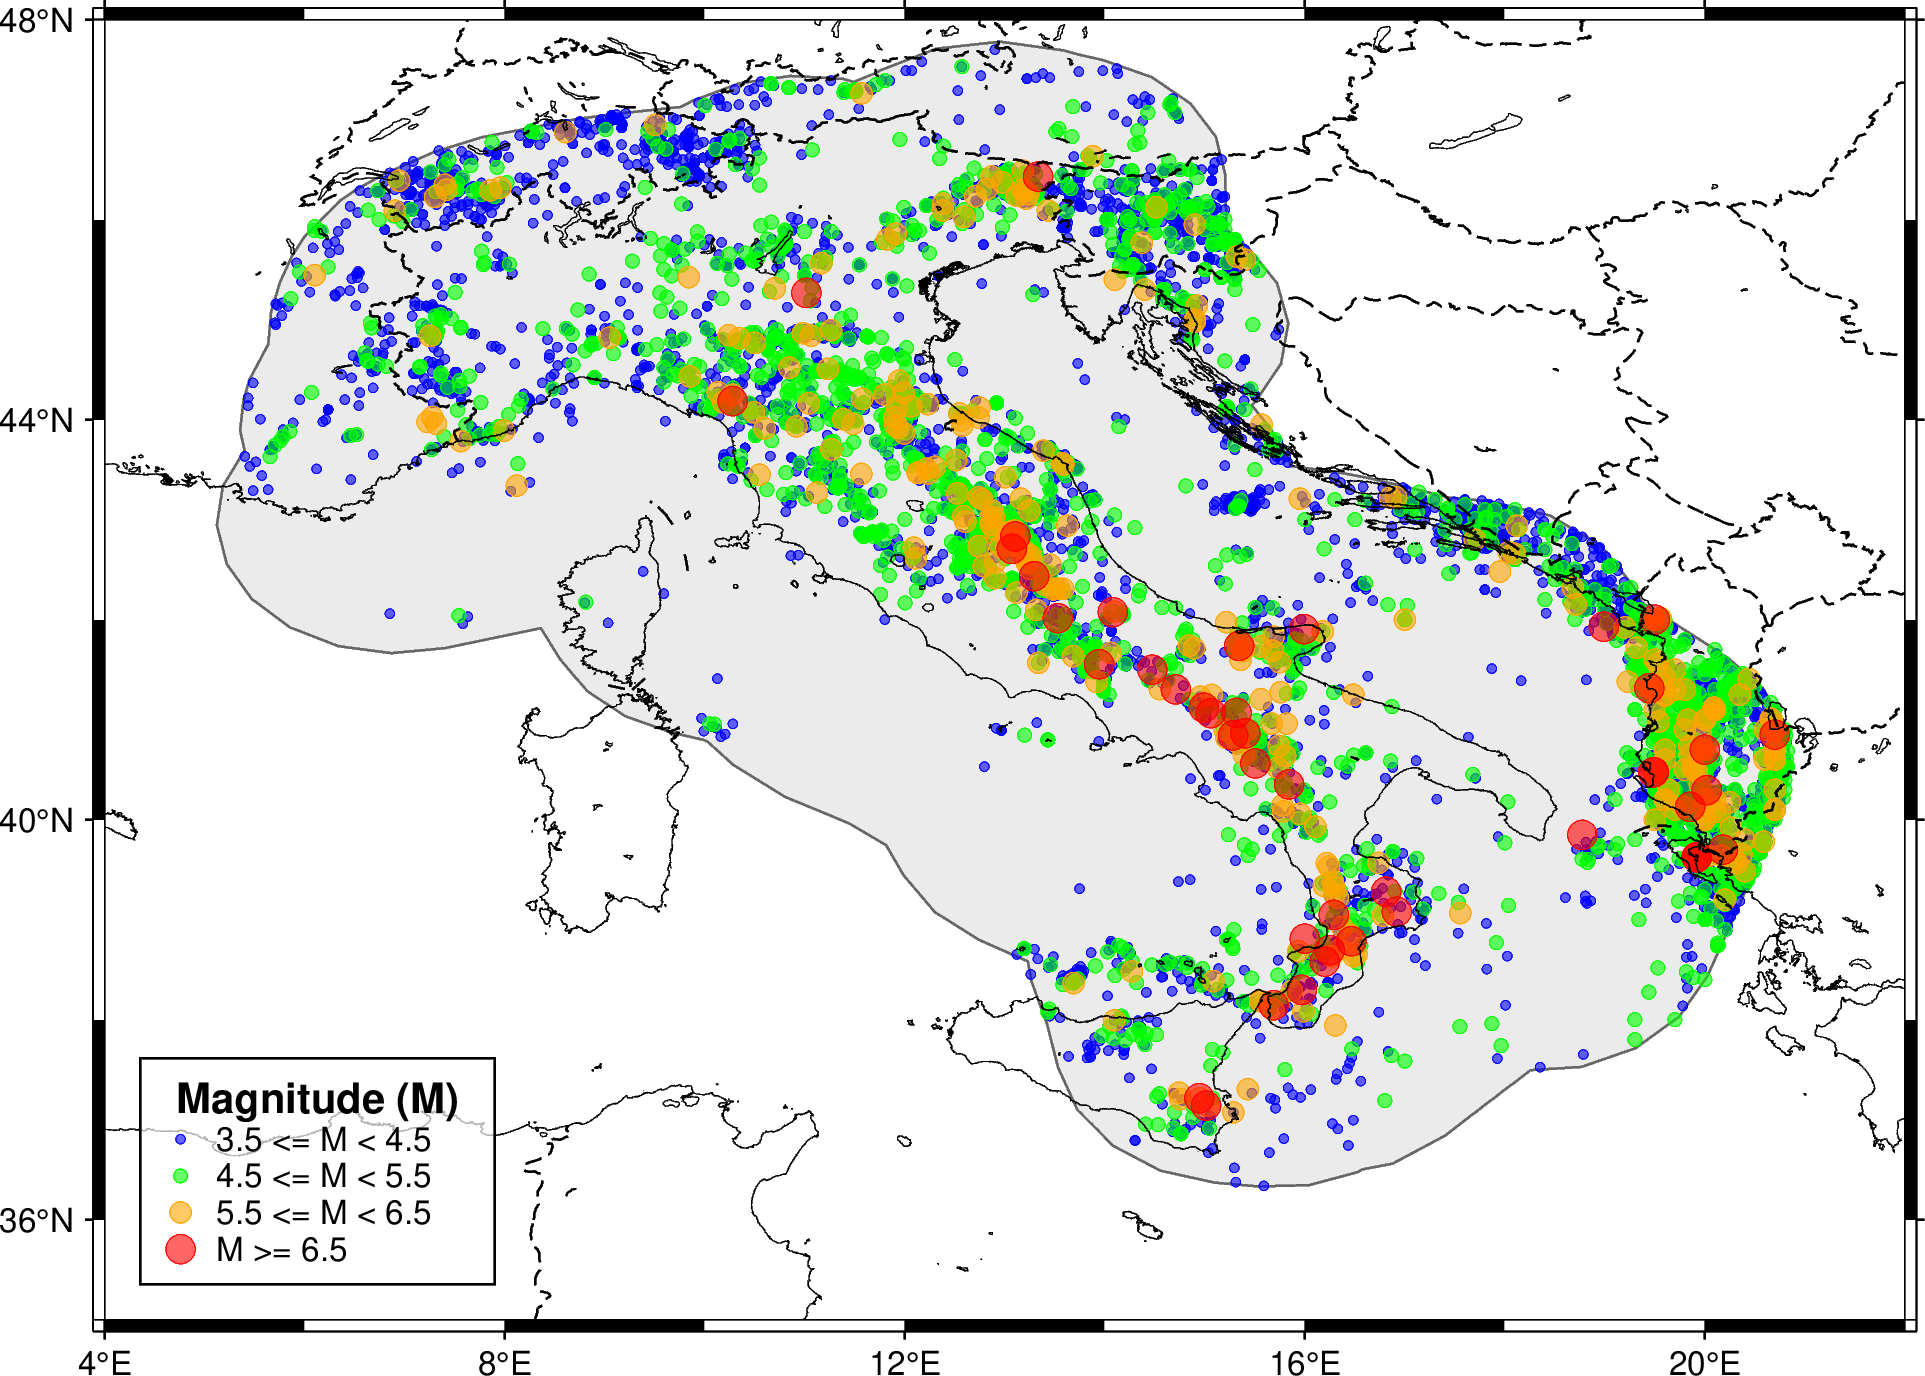

In [5]:
output_dir = os.path.join("..", "output")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

file_name = "cat_it_map.png"
output_map = os.path.join(output_dir, file_name)

visualize_catalogue(
    catalogue=catalogue,
    polygon=polygon,
    region=it_region,
    output_png=output_map,
    bins=custom_bins
)

display(Image(filename=output_map))